# Data Retrieval

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
train= pd.read_csv('data/train.csv')
test= pd.read_csv('data/test.csv')

In [3]:
print(f"Train shape: {train.shape}, Test shape: {test.shape}")
print(train.head())

Train shape: (1460, 81), Test shape: (1459, 80)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  

In [4]:
def optimize_memory(df): 
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype('float32')
    

In [5]:
optimize_memory(train)
optimize_memory(test)

# Data Cleaning

### Constant Value Filling ('None'):
For features like PoolQC, MiscFeature, Alley, and Fence, a "NaN" value represents the absence of the feature rather than missing information. We fill these with 'None' to treat them as a valid category for the model
### Mode Imputation: 
For other categorical features (Electrical, GarageType), we use the Mode (the most frequent value) to fill gaps with the most common observation in the dataset.

### Median Imputation:
For the numerical feature LotFrontage, we utilize the Median. 

In [6]:
def clean_missing_values(df):
    cols_with_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
    for col in cols_with_none:
        df[col] = df[col].fillna('None')
        
    columns_null=['MasVnrType','FireplaceQu','GarageFinish','GarageYrBlt','GarageQual','GarageCond'
              ,'GarageType','BsmtFinType2','BsmtExposure','BsmtQual','BsmtFinType1','BsmtCond','MasVnrArea','Electrical']
    for col in columns_null:
        df[col]=df[col].fillna(df[col].mode()[0])
        
    df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

In [7]:
clean_missing_values(train)
clean_missing_values(test)

In [8]:
train.isnull().sum().sort_values(ascending=False).head(5)

Id             0
CentralAir     0
GarageYrBlt    0
GarageType     0
FireplaceQu    0
dtype: int64

# Exploratory Data Analysis (EDA)


### Identifying Correlation: 
We want to confirm the strong positive correlation between the house's size and its final sale price.
### Detecting Outliers: 
This visualization allows us to spot "Outliers"—specifically, houses with extremely large living areas that were sold for 
.
 By observing how closely the price follows the area, we can justify why GrLivArea is one of the most important features to include in our model.

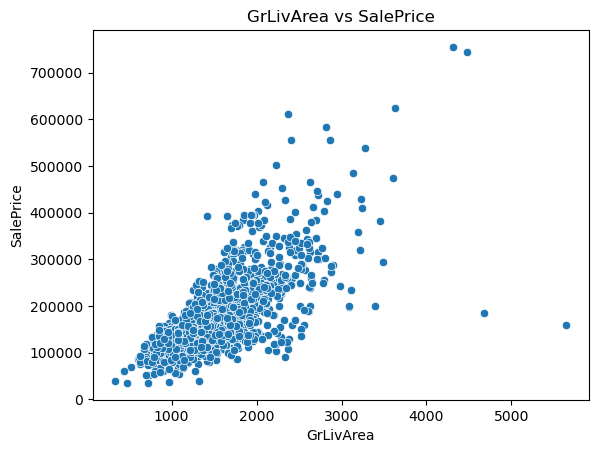

In [9]:
sns.scatterplot(x=train['GrLivArea'], y=train['SalePrice'])
plt.title("GrLivArea vs SalePrice")
plt.show()

We are removing houses with a GrLivArea greater than 4,000 square feet that were sold for less than $300,000.

In [10]:
train = train.drop(train[(train['GrLivArea']>4000) & (train['SalePrice']<300000)].index)

One of the key requirements for linear regression is that the target variable should follow a Normal Distribution. However, the original SalePrice in this dataset is right-skewed, meaning most houses are in the lower price range with a few very expensive ones pulling the tail to the right

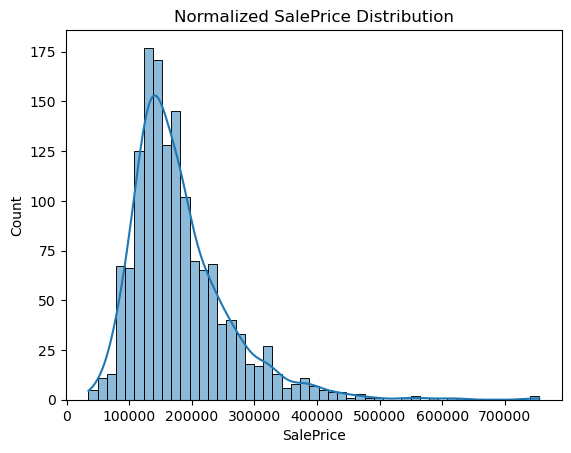

In [11]:
sns.histplot(train["SalePrice"], kde=True)
plt.title("Normalized SalePrice Distribution")
plt.show()

We apply np.log1p to the SalePrice to reduce the skewness and make the distribution more bell-shaped (Normal)

In [12]:
train['SalePrice'] = np.log(train['SalePrice'])

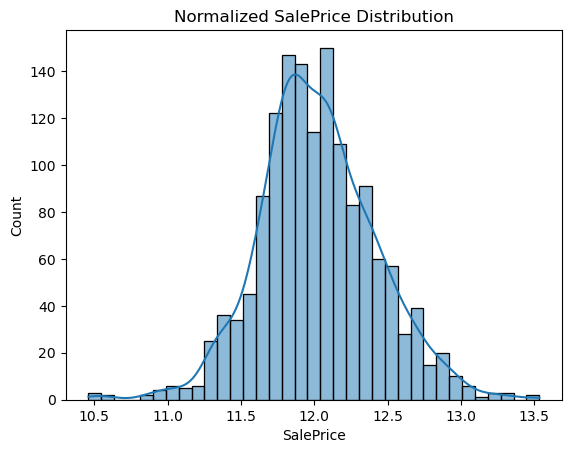

In [13]:
sns.histplot(train["SalePrice"], kde=True)
plt.title("Normalized SalePrice Distribution")
plt.show()

### orrelation Matrix: 
We compute the correlation coefficients for all numerical features relative to SalePrice.
### Top 5 Features: 
We identify the top 5 features most strongly correlated with the price. Note that we use .head(6) in the code because the highest correlation (1.0) is always SalePrice with itself
### Heatmap Visualization:
Using Seaborn, we generate a heatmap to visualize these relationships. The color intensity and the annotated values (annot=True) allow us to quickly identify which factors, such as quality or living area, dominate the market

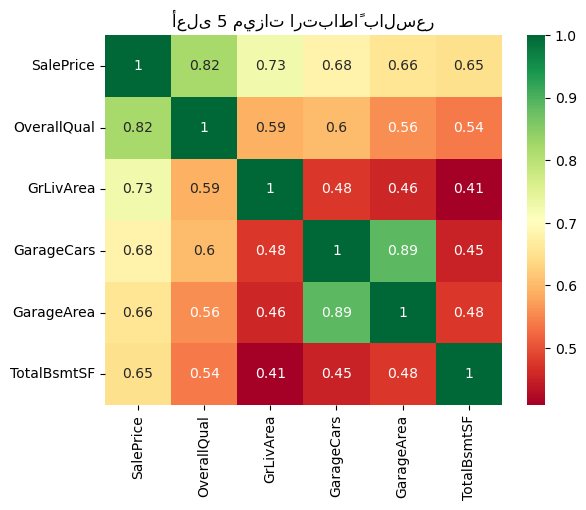

In [14]:
top_corr = train.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False).head(6)
sns.heatmap(train[top_corr.index].corr(), annot=True, cmap='RdYlGn')
plt.title("أعلى 5 ميزات ارتباطاً بالسعر")
plt.show()

### Confirming Linear Relationship:
We expect to see a strong positive correlation where larger homes generally command higher prices.
### Quality Impact: 
By using the hue='OverallQual' parameter, we can observe if higher-quality homes (lighter colors) consistently sit at higher price points compared to lower-quality homes of the same size


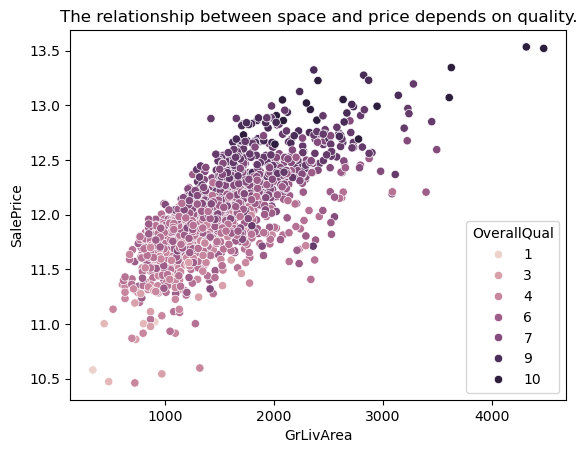

In [15]:
sns.scatterplot(data=train, x='GrLivArea', y='SalePrice', hue='OverallQual')
plt.title("The relationship between space and price depends on quality.")
plt.show()

 the data and calculating the mean, we can clearly identify which neighborhoods are the most expensive. We focus on the Top 10 neighborhoods to provide a clear, high-level insight.
### Use of Log-Transformed Prices:
This chart displays the average of the Log-Transformed SalePrice. This maintains consistency with our previous normalization step and ensures that extreme price outliers in certain neighborhoods do not distort the overall geographical trend
.
### Justifying Categorical Encoding:
Visualizing these differences helps justify why the Neighborhood feature is a strong candidate for One-Hot Encoding in the next phase of the project


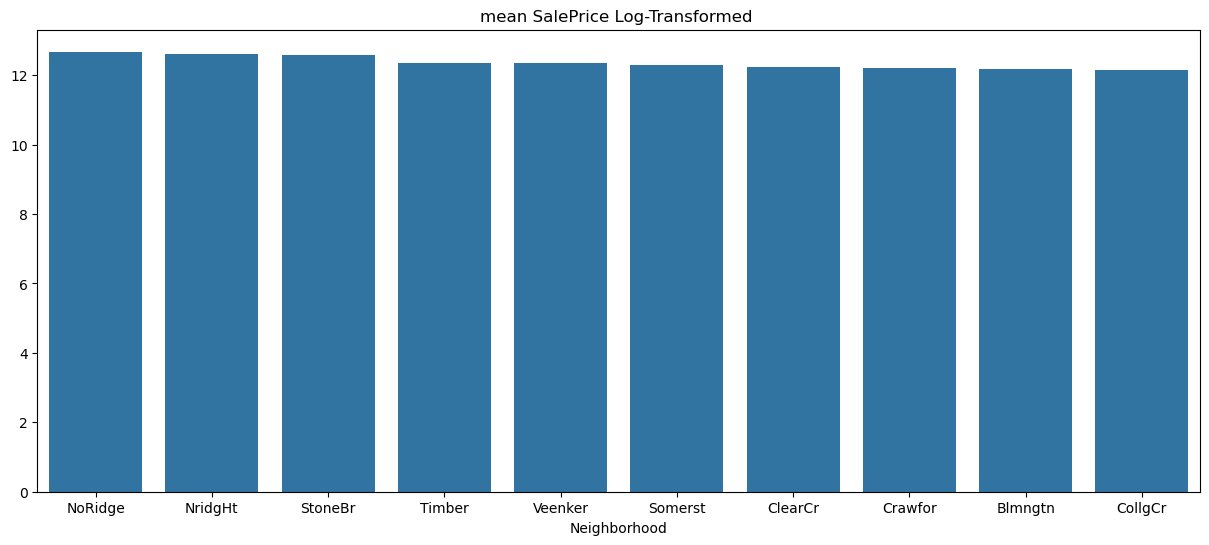

In [16]:
neigh_avg = train.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(15, 6))
sns.barplot(x=neigh_avg.index, y=neigh_avg.values)
plt.title("mean SalePrice Log-Transformed ")
plt.show()


# 4. Feature Engineering

### eature Transformation (TotalSF): 
We created a new feature, TotalSF, by summing the square footage of the basement, the first floor, and the second floor
. This provides a single, comprehensive measure of the house's total living space, which is often a stronger predictor of price than individual floor areas.
### Handling Ordinal Features (Label Encoding): 
For features with an inherent rank (e.g., ExterQual, KitchenQual), we applied Label Encoding using a custom mapping This preserves the logical order (e.g., "Excellent" > "Good" > "Typical") as numerical values (5, 4, 3), allowing the model to understand the qualitative hierarchy.
### Handling Nominal Features (One-Hot Encoding): 
For categorical features without a specific order (e.g., Neighborhood, BldgType), we used One-Hot Encoding via pd.get_dummies . This prevents the model from assuming a false mathematical relationship between categories that are simply distinct names

In [17]:
def apply_feature_engineering(df):
    
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF'] 
    
    qual_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0}
    
    ordinal_cols = ['ExterCond','ExterQual', 'KitchenQual', 'BsmtQual', 'HeatingQC']
    for col in ordinal_cols:
            df[col] = df[col].map(qual_map).fillna(0) 
            
    df = pd.get_dummies(df, columns=['Neighborhood', 'BldgType', 'HouseStyle'])


In [18]:
apply_feature_engineering(train)
apply_feature_engineering(test)

In [19]:
train['BsmtQual']

0       4
1       4
2       4
3       3
4       4
       ..
1455    4
1456    4
1457    3
1458    3
1459    3
Name: BsmtQual, Length: 1458, dtype: int64